In [ ]:
from preprocess_graph_data import CPDataSet
from torch_geometric.data import DataLoader

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
dataset = CPDataSet(root = '../graphdata/CP_Studies_llqq_graphs')
example_nodes = torch.cat([dataset[i].x for i in range(10000)], dim=0)

In [ ]:
print("Feature Means:")
print(example_nodes.mean(dim=0))
print("\nFeature Standard Deviations:")
print(example_nodes.std(dim=0))
print("----------------------------\n")

In [ ]:
example_nodes[179173][7]

In [ ]:
all_lumi_weights = torch.cat([i.lumi_weight for i in dataset])


In [ ]:
import h5py
import numpy as np
import torch
from preprocess_graph_data import CPDataSet, hfivesdir, graphsdir

def validate_single_event(dataset, event_index):
    """
    Checks a single event by comparing the processed graph data against the original HDF5 source.
    """
    print("-" * 50)
    print(f"--- VALIDATING EVENT INDEX: {event_index} ---")

    # --- 1. Load the processed graph from your dataset ---
    try:
        processed_graph = dataset.get(event_index)
        processed_nodes = processed_graph.x
        print(f"Successfully loaded processed graph with {processed_nodes.shape[0]} nodes.")
    except Exception as e:
        print(f"ERROR: Could not load processed graph for index {event_index}. Error: {e}")
        return False

    # --- 2. Load the original raw data from the HDF5 file ---
    with h5py.File(hfivesdir, 'r') as f:
        # Get the structured array for ALL constituents of the specific event
        raw_event_constituents = f['LargeRJet']['2d'][event_index]
        feature_names = raw_event_constituents.dtype.names
        
        # Get event-level data for this event (for label/lumi weight check)
        raw_event_1d = f['LargeRJet']['1d'][event_index]

    # --- 3. Apply the SAME filtering logic as in your process() method ---
    # Create a simple float array from the structured array for easier indexing
    raw_nodes_unstructured = np.zeros((raw_event_constituents.shape[0], len(feature_names)), dtype=np.float32)
    for i, name in enumerate(feature_names):
        raw_nodes_unstructured[:, i] = raw_event_constituents[name]

    # Apply the mask (pt > 0)
    pt_idx = feature_names.index('constituent_pt')
    valid_mask = raw_nodes_unstructured[:, pt_idx] > 0
    raw_valid_nodes = raw_nodes_unstructured[valid_mask]
    raw_valid_nodes = np.nan_to_num(raw_valid_nodes, nan=0.0) # Ensure NaNs are handled identically
    
    print(f"Found {raw_valid_nodes.shape[0]} valid nodes in the original HDF5 data.")

    # --- 4. Perform the Comparisons ---
    all_checks_passed = True
    
    # Check if the number of nodes matches
    if processed_nodes.shape[0] != raw_valid_nodes.shape[0]:
        print(f"ERROR: Node count mismatch! Processed: {processed_nodes.shape[0]}, Raw: {raw_valid_nodes.shape[0]}")
        all_checks_passed = False
        return all_checks_passed
    else:
        print("  -> Node count matches. OK.")

    # Check each feature column
    print("  -> Comparing feature columns...")
    processed_nodes_np = processed_nodes.numpy() # Convert to NumPy for easy comparison
    
    for i, name in enumerate(feature_names):
        processed_col = processed_nodes_np[:, i]
        raw_col = raw_valid_nodes[:, i]
        
        # np.allclose is better than == for floating point numbers
        if np.allclose(processed_col, raw_col, atol=1e-6):
            print(f"     '{name}' column: MATCH")
        else:
            print(f"     '{name}' column: MISMATCH!")
            # Print a few examples of the mismatch
            for j in range(min(5, len(processed_col))):
                print(f"        Node {j}: Processed={processed_col[j]}, Raw={raw_col[j]}")
            all_checks_passed = False

    # --- 5. Bonus Checks: Compare Graph-Level Attributes ---
    # Check the label
    raw_lumi = raw_event_1d['Lumi_weight']
    expected_label = 1 if raw_lumi > 0 else 0
    if processed_graph.y.item() == expected_label:
        print("  -> Graph label 'y' matches original Lumi_weight sign. OK.")
    else:
        print("ERROR: Graph label mismatch!")
        all_checks_passed = False

    # Check the lumi_weight itself
    if np.isclose(processed_graph.lumi_weight.item(), raw_lumi):
        print("  -> Graph 'lumi_weight' attribute matches original. OK.")
    else:
        print("ERROR: Graph lumi_weight mismatch!")
        all_checks_passed = False
        
    print(f"--- VALIDATION FOR EVENT {event_index} COMPLETE: {'PASSED' if all_checks_passed else 'FAILED'} ---")

In [ ]:
import h5py
import numpy as np
import torch
from preprocess_graph_data import CPDataSet, hfivesdir, graphsdir

In [ ]:
print("Loading the full dataset...")
dataset = CPDataSet(root=graphsdir)
print("Dataset loaded.")

# # Pick a few random indices to check
# num_to_check = 5
# random_indices = np.random.choice(len(dataset), num_to_check, replace=False)

# results = []
# for idx in random_indices:
#     results.append(validate_single_event(dataset, idx))

# print("=" * 50)
# print("\nVALIDATION SUMMARY:")
# if all(results):
#     print(f"All {num_to_check} randomly checked events passed validation successfully!")
# else:
#     print(f"One or more events FAILED validation. Please review the logs above.")
# print("=" * 50)

In [ ]:
dataset[0]

In [ ]:
import numpy as np

In [ ]:
data = np.load('../graphdata/gnn_discriminant_scores.npz')
discriminant_scores = data['discriminant_scores']
Lumi_weights = data['lumi_weights']

In [ ]:
positives = Lumi_weights[l]

In [ ]:
import numpy as np

In [ ]:
data = np.load(r"C:\Users\colel\OneDrive\Documents\UoE_UG\Y4\SH_Project\SH-Project\graphdata\gnn_discriminant_scores_20th_October_Linear.npz")
discriminant_Scores = data['discriminant_scores']
Lumi_weights = data['lumi_weights'] 

In [ ]:
unique,counts = np.unique(discriminant_Scores, return_counts = True)
print(unique)

print(counts)

In [ ]:
unique_counts = np.unique(Lumi_weights > 0) #every lumi weight is positive in quadratic term
print(unique_counts)

In [ ]:
from preprocess_graph_data import CPDataSet

In [ ]:
dataset = CPDataSet(root = '../graphdata/CP_Studies_llqq_graphs_20th_October_Linear')

In [ ]:
dataset[0].x[:,5] #column 6 of each node is isLep should be one for every datapoint
print(len(dataset[0].x[:,5]))

In [ ]:
#check only leptons are being saved:

l = 10000

for i in range(l):
    if any(dataset[i].x[:,5]) != 1 :
        print('Saved non-lepton at index ' +str(i))
        break
print('Only leptons saved')

In [ ]:
for i in range(10):
    print(dataset[i].edge_index)

In [ ]:
nlep = 0
for i in range(10000):
    nlep = max(nlep,len(dataset[i].x[:,5]))

print(nlep) #always two leptons, makes sense cause that's decay final state

In [ ]:
dataset = CPDataSet(root = '../graphdata/CP_Studies_llqq_graphs_20th_October_Quadratic')

all_positive = True
for i in range(10000,len(dataset)):
    if dataset[i].lumi_weight < 0:
        all_positive = False
        print('negative lumi weight at ' +str(i))

print(all_positive)

In [ ]:
from lepton_data_process import CPDataSet
lepton_set = CPDataSet(root = '../graphdata/CP_Studies_llqq_graphs_20th_October_Linear',
                       hfivesdir='../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5')

In [ ]:
lepton_set[29].x[:,7]

for i in range(10000):
    if any(lepton_set[i].x[:,7]) <= 0:
        print("Negative pt value at " + str(i))
print('no negative pt')

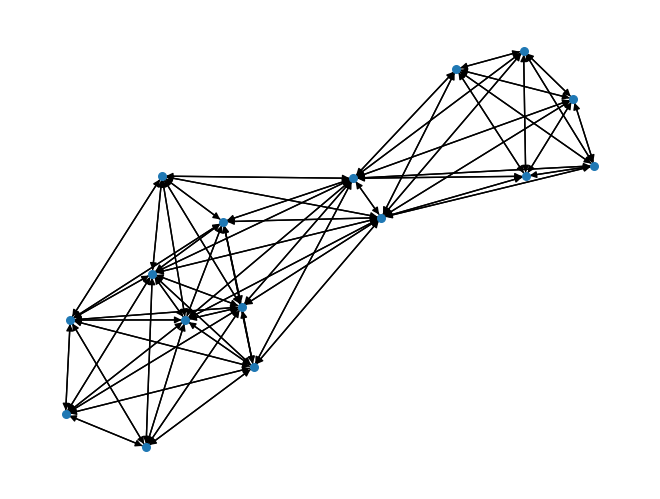

In [7]:
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx
from GNN_preprocess import CPDataSet

dataset = CPDataSet(root = '../graphdata/CP_Studies_llqq_graphs_20th_October_Linear_full',
hfivesdir='../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5',
lepton_only = False)
data = dataset[8]
G = to_networkx(data)
nx.draw(G, node_size=30)
plt.show()